# ***Task 2: Exploratory Data Analysis (EDA)***

In [2]:
from google.colab import files

uploaded = files.upload()

Saving Titanic-Dataset.csv to Titanic-Dataset.csv


In [11]:
import pandas as pd

df = pd.read_csv("Titanic-Dataset.csv")

df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

%matplotlib inline

In [12]:
df.head()

print("Rows and Columns:", df.shape)

df.info()

df.isnull().sum()

Rows and Columns: (891, 12)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


**Generate** **Summary** **Statistics**

In [13]:
df.describe()

df.mean(numeric_only=True)

df.median(numeric_only=True)

df.std(numeric_only=True)

df.var(numeric_only=True)

df.skew(numeric_only=True)

df.kurt(numeric_only=True)

,0
PassengerId,-1.200000
Survived,-1.775005
Pclass,-1.280015
Age,0.178274
SibSp,17.880420
Parch,9.778125
Fare,33.398141


Histograms for Numeric Features

- All numeric columns

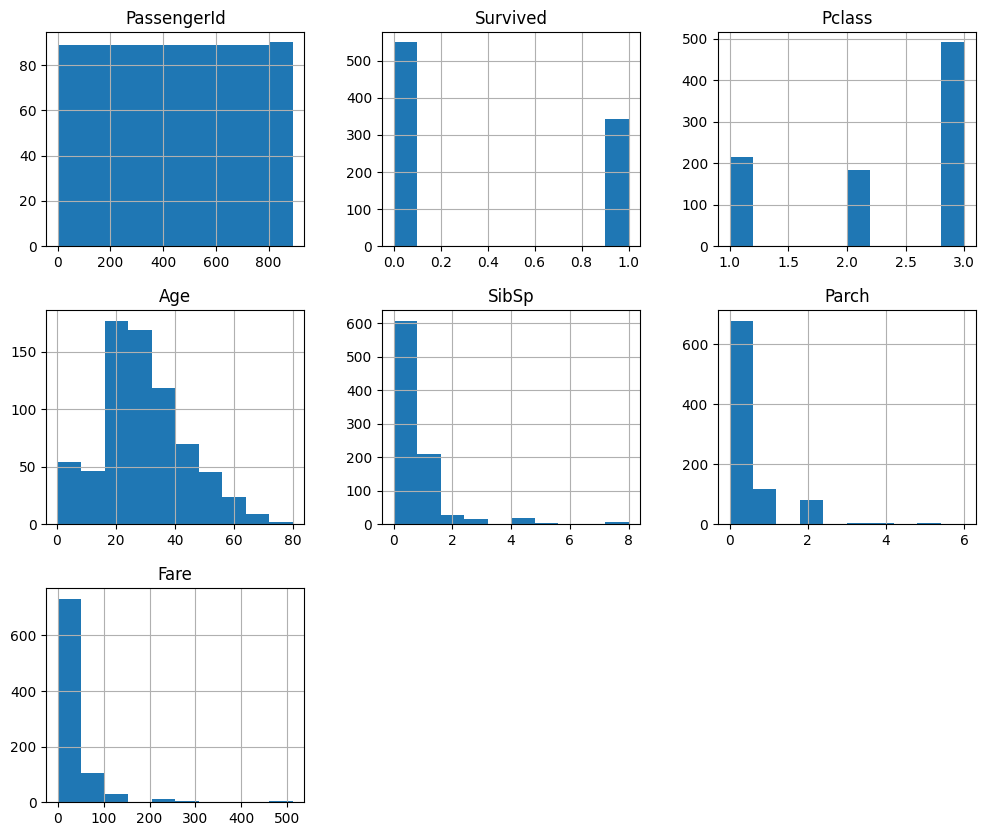

In [14]:
df.hist(figsize=(12,10))
plt.show()

- Age distribution

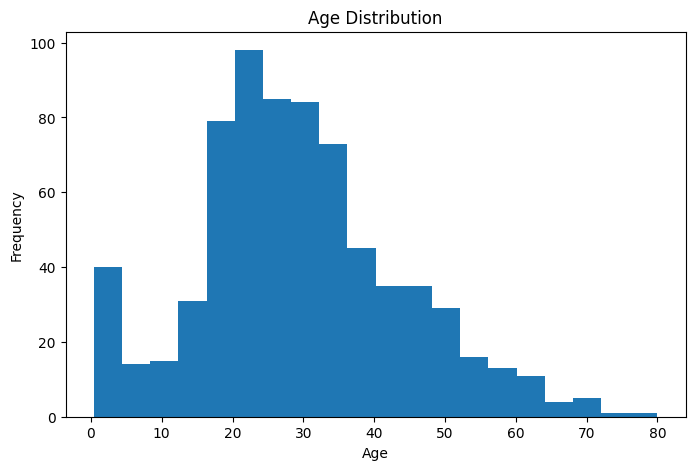

In [15]:
plt.figure(figsize=(8,5))

plt.hist(df['Age'].dropna(), bins=20)

plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")

plt.show()

- Fare Distribution

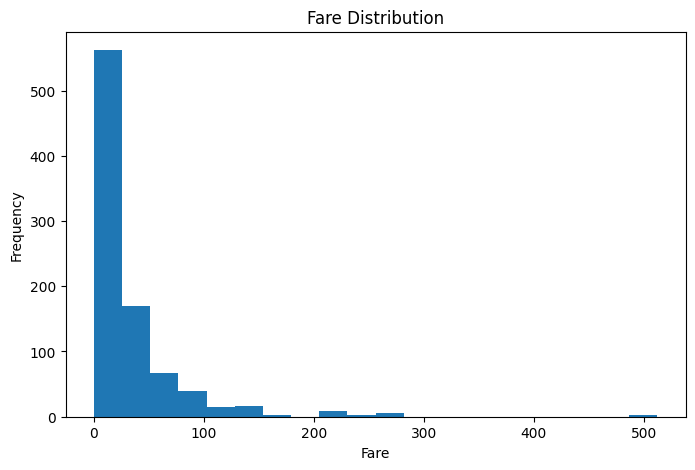

In [16]:
plt.figure(figsize=(8,5))

plt.hist(df['Fare'], bins=20)

plt.title("Fare Distribution")
plt.xlabel("Fare")
plt.ylabel("Frequency")

plt.show()

- Boxplots for Outlier Detection

- Age Boxplot

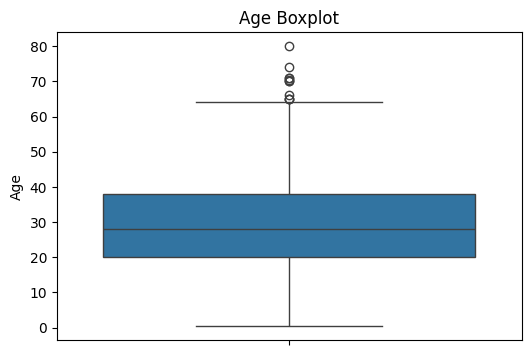

In [17]:
plt.figure(figsize=(6,4))

sns.boxplot(y=df['Age'])

plt.title("Age Boxplot")
plt.show()

- Fare Boxplot

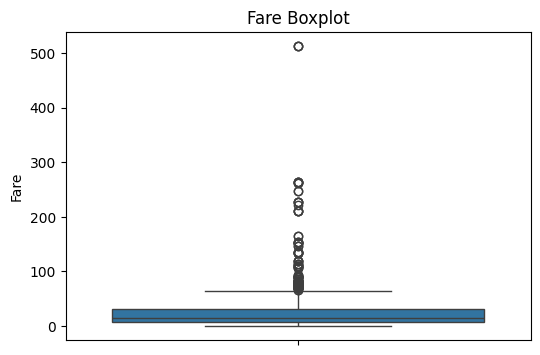

In [18]:
plt.figure(figsize=(6,4))

sns.boxplot(y=df['Fare'])

plt.title("Fare Boxplot")
plt.show()

- All Numeric Columns

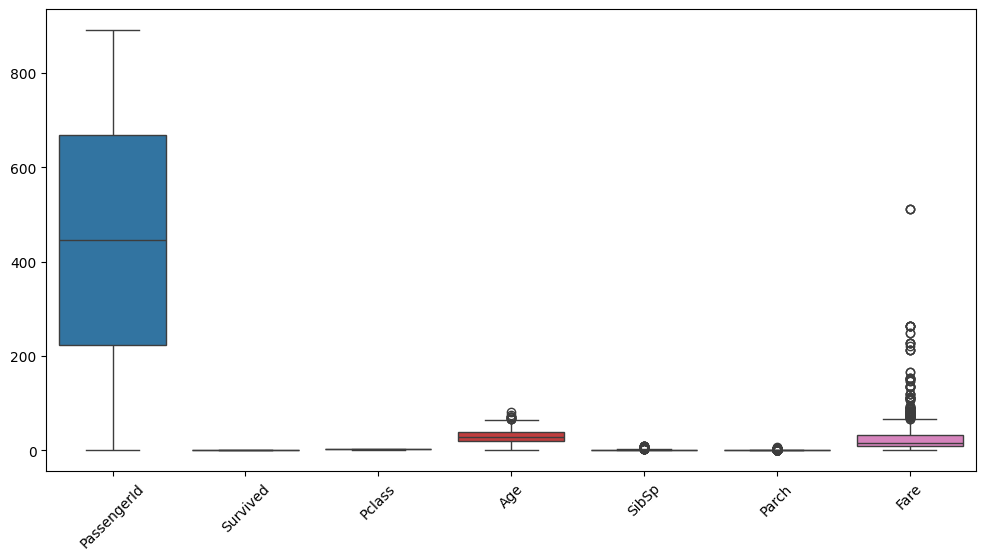

In [19]:
numeric_cols = df.select_dtypes(include=np.number)

plt.figure(figsize=(12,6))

sns.boxplot(data=numeric_cols)

plt.xticks(rotation=45)

plt.show()

**Correlation** **Matrix**

Calculate Correlation

In [20]:
correlation = numeric_cols.corr()

correlation

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
PassengerId,1.000000,-0.005007,-0.035144,0.036847,-0.057527,-0.001652,0.012658
Survived,-0.005007,1.000000,-0.338481,-0.077221,-0.035322,0.081629,0.257307
Pclass,-0.035144,-0.338481,1.000000,-0.369226,0.083081,0.018443,-0.549500
Age,0.036847,-0.077221,-0.369226,1.000000,-0.308247,-0.189119,0.096067
SibSp,-0.057527,-0.035322,0.083081,-0.308247,1.000000,0.414838,0.159651
Parch,-0.001652,0.081629,0.018443,-0.189119,0.414838,1.000000,0.216225
Fare,0.012658,0.257307,-0.549500,0.096067,0.159651,0.216225,1.000000


Heatmap Visualization

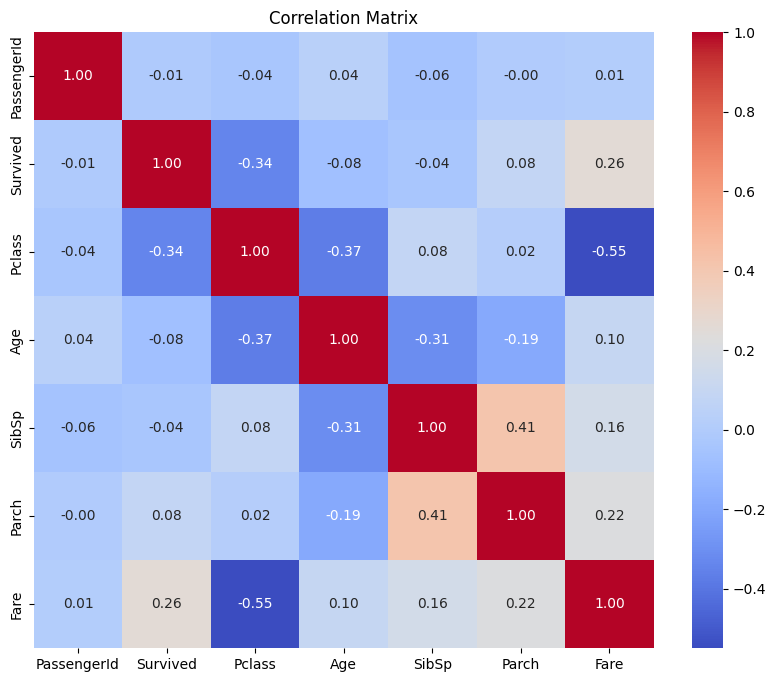

In [21]:
plt.figure(figsize=(10,8))

sns.heatmap(
    correlation,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title("Correlation Matrix")

plt.show()

**Pairplot for Feature Relationships**

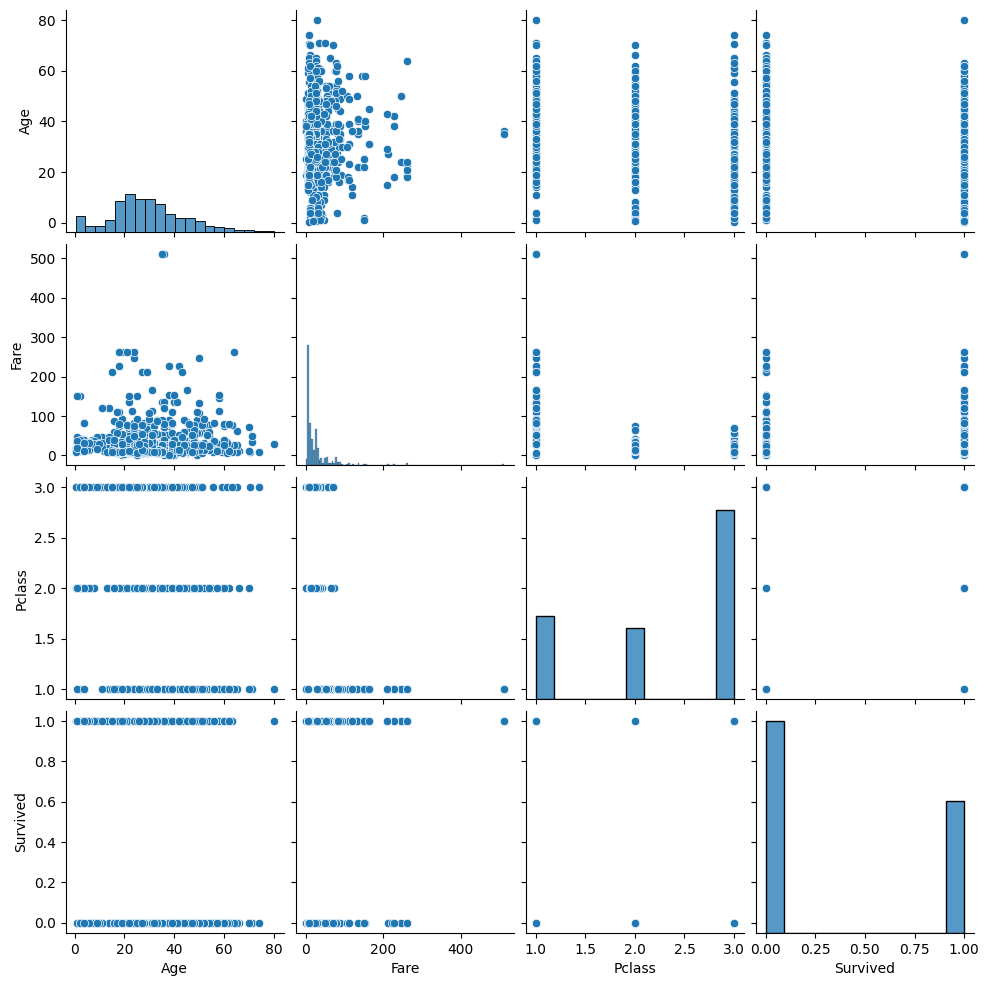

In [22]:
sns.pairplot(
    df[['Age','Fare','Pclass','Survived']]
)

plt.show()

**Survival Analysis**

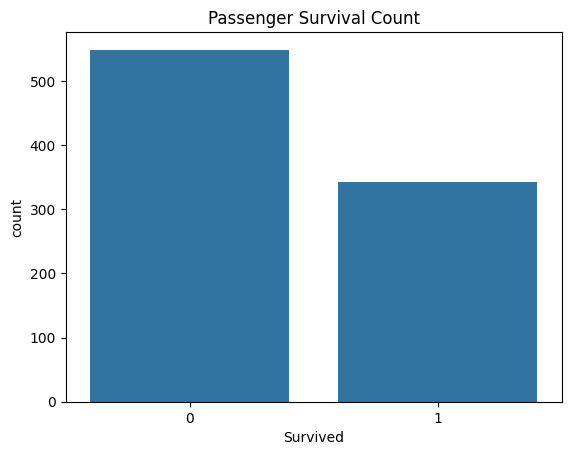

In [23]:
sns.countplot(x='Survived', data=df)

plt.title("Passenger Survival Count")

plt.show()

**Survival by Gender**

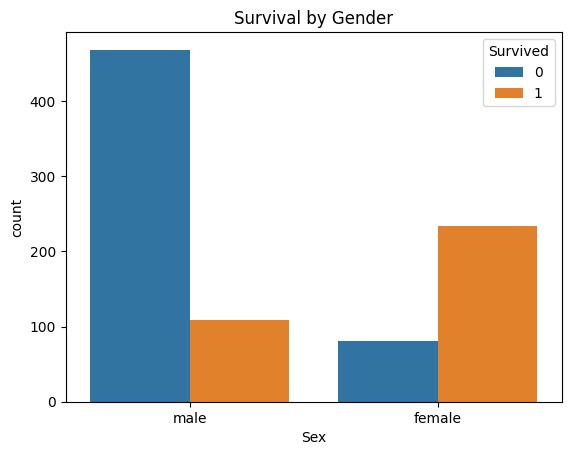

In [24]:
sns.countplot(
    x='Sex',
    hue='Survived',
    data=df
)

plt.title("Survival by Gender")

plt.show()

**Survival by Passenger Class**

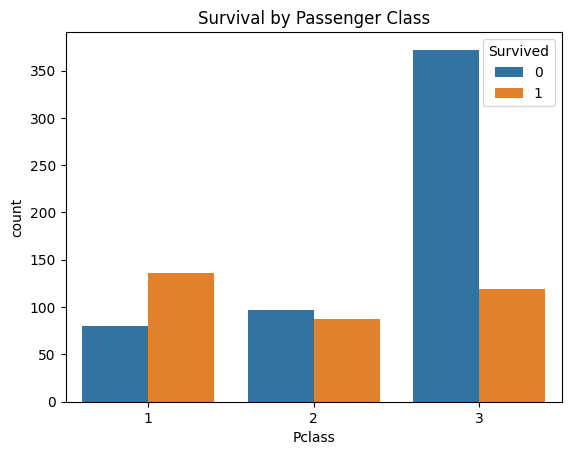

In [25]:
sns.countplot(
    x='Pclass',
    hue='Survived',
    data=df
)

plt.title("Survival by Passenger Class")

plt.show()

**Interactive Plotly Visualization**

In [26]:
fig = px.scatter(
    df,
    x='Age',
    y='Fare',
    color='Survived',
    title='Age vs Fare'
)

fig.show()

**Identify Patterns and Trends**

Average Age

In [27]:
print("Average Age:", df['Age'].mean())

Average Age: 29.69911764705882


Average Fare

In [28]:
print("Average Fare:", df['Fare'].mean())

Average Fare: 32.204207968574636


Survival by Gender

In [29]:
df.groupby('Sex')['Survived'].mean()

,Survived
Sex,
female,0.742038
male,0.188908


Survival by Class

In [30]:
df.groupby('Pclass')['Survived'].mean()

,Survived
Pclass,
1,0.629630
2,0.472826
3,0.242363


**Feature-Level Inferences**

Inference 1

Females had a significantly higher survival rate than males.

Inference 2

Passengers in First Class had better survival chances than those in Third Class.

Inference 3

The Fare feature contains several high-value outliers visible in the boxplot.

Inference 4

Age distribution is approximately right-skewed with most passengers between 20–40 years.

Inference 5

Fare and Passenger Class show noticeable correlation.

Inference 6

Several missing values exist in the Age and Cabin columns.